In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
pd.options.display.max_columns = 99

In [2]:
df = pd.read_csv("/content/online_shoppers_intention.csv")

In [3]:
df.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [5]:
LE = LabelEncoder()
df['Month'] = LE.fit_transform(df['Month'])
df['VisitorType'] = LE.fit_transform(df['VisitorType'])
df['Weekend'] = LE.fit_transform(df['Revenue'])
df['Revenue'] = LE.fit_transform(df['Revenue'])

In [6]:
df.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,2,1,1,1,1,2,0,0
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,2,2,2,1,2,2,0,0
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,2,4,1,9,3,2,0,0
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,2,3,2,2,4,2,0,0
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,2,3,3,1,4,2,0,0
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,2,2,2,1,3,2,0,0
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,2,2,4,3,3,2,0,0
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,2,1,2,1,5,2,0,0
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,2,2,2,2,3,2,0,0
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,2,2,4,1,2,2,0,0


In [7]:
df.shape

(12330, 18)

In [8]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,5.163990,2.124006,2.357097,3.147364,4.069586,1.718329,0.154745,0.154745
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,2.370199,0.911325,1.717277,2.401591,4.025169,0.690759,0.361676,0.361676
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,5.000000,2.000000,2.000000,1.000000,2.000000,2.000000,0.000000,0.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,2.000000,0.000000,0.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,7.000000,3.000000,2.000000,4.000000,4.000000,2.000000,0.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,9.000000,8.000000,13.000000,9.000000,20.000000,2.000000,1.000000,1.000000


In [9]:
X_question = df.iloc[:,0:15]
q_mean = X_question.mean(axis=0)
total_mean = q_mean.mean()

In [10]:
q_mean = q_mean.to_frame('mean')
q_mean.reset_index(level=0,inplace=True)
q_mean

,index,mean
0,Administrative,2.315166
1,Administrative_Duration,80.818611
2,Informational,0.503569
3,Informational_Duration,34.472398
4,ProductRelated,31.731468
5,ProductRelated_Duration,1194.746220
6,BounceRates,0.022191
7,ExitRates,0.043073
8,PageValues,5.889258
9,SpecialDay,0.061427


<Axes: >

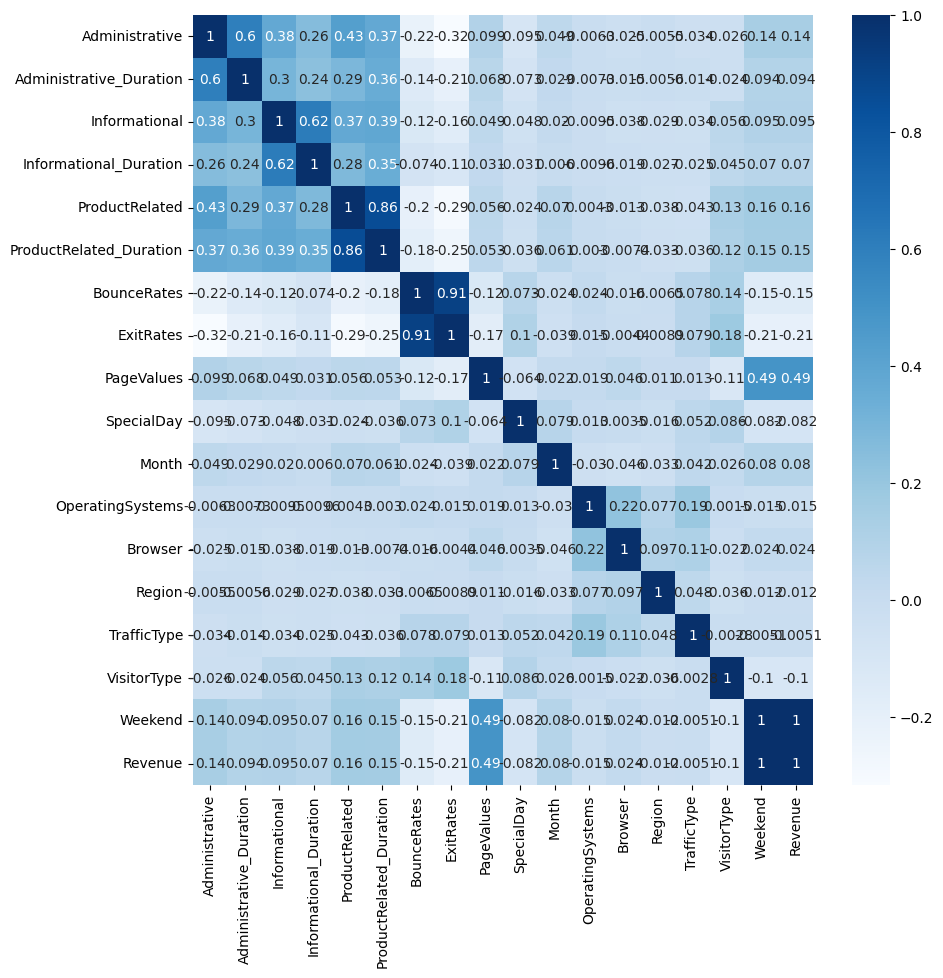

In [11]:
corr = df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr,annot=True,cmap = 'Blues')

<Axes: xlabel='index', ylabel='mean'>

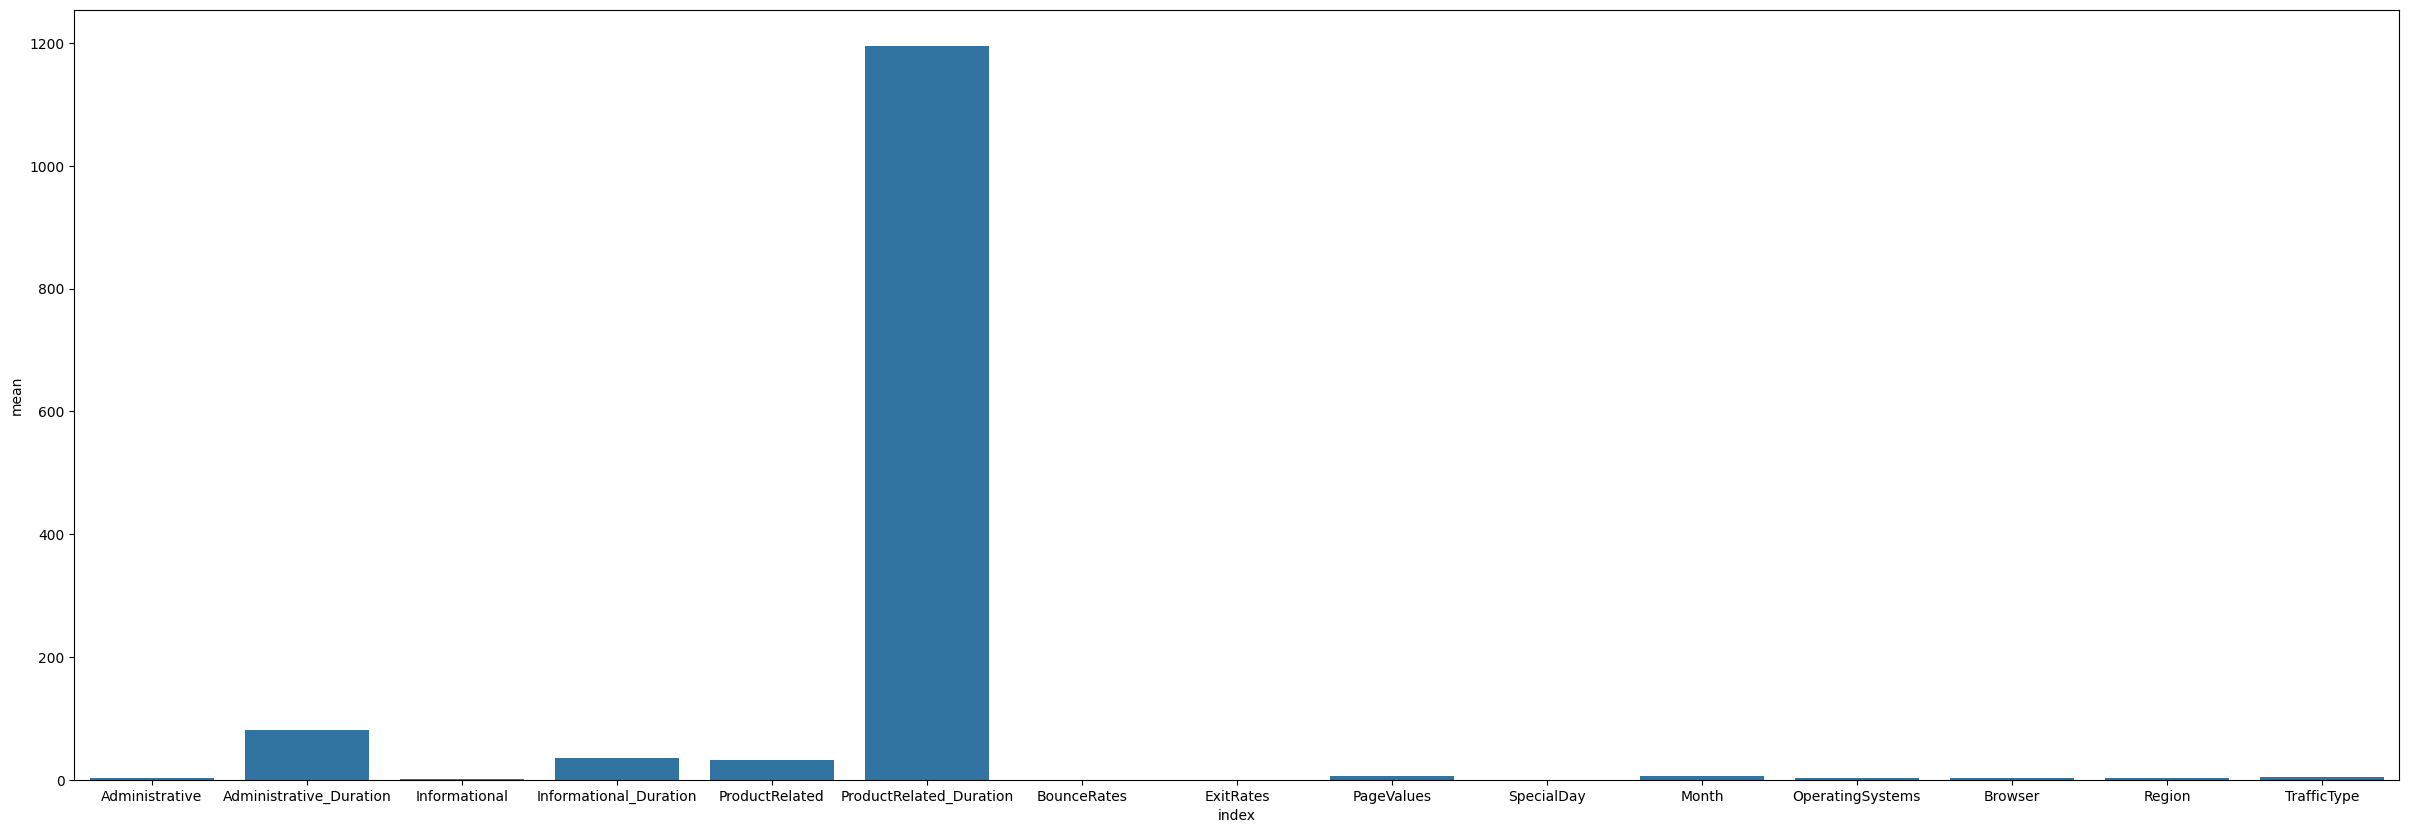

In [12]:
plt.figure(figsize=(30,10))
sns.barplot(x='index',y='mean',data=q_mean)

<Axes: ylabel='count'>

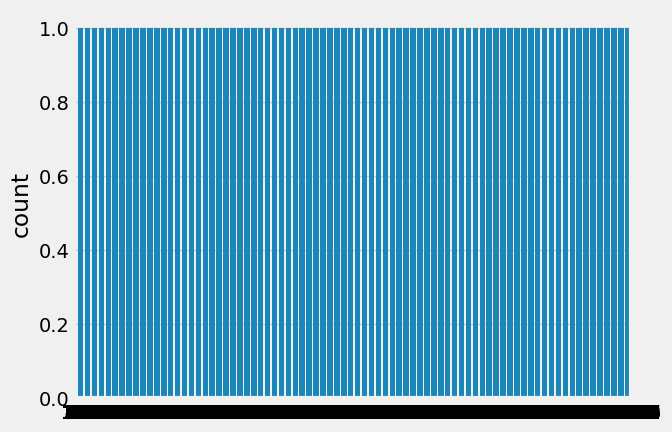

In [13]:
plt.style.use('fivethirtyeight')
sns.countplot(df['Administrative'])

In [14]:
X = df.iloc[:,0:15]
pca = PCA(n_components=2,random_state=42)
X_pca = pca.fit_transform(X)


In [15]:
X_pca

array([[-1197.63556861,   -40.8240305 ],
       [-1133.68457048,   -43.29111063],
       [-1197.63604944,   -40.82404362],
       ...,
       [-1013.48455522,   -47.94064613],
       [ -849.24644153,    18.23948513],
       [-1176.36817289,   -41.65409407]])

In [18]:
X_pca = pd.DataFrame(X_pca)
X_pca.columns = ['PCA 1','PCA 2']

In [19]:
X_pca.head()

,PCA 1,PCA 2
0,-1197.635569,-40.824031
1,-1133.684570,-43.291111
2,-1197.636049,-40.824044
3,-1194.952059,-40.933612
4,-570.631553,-65.005349


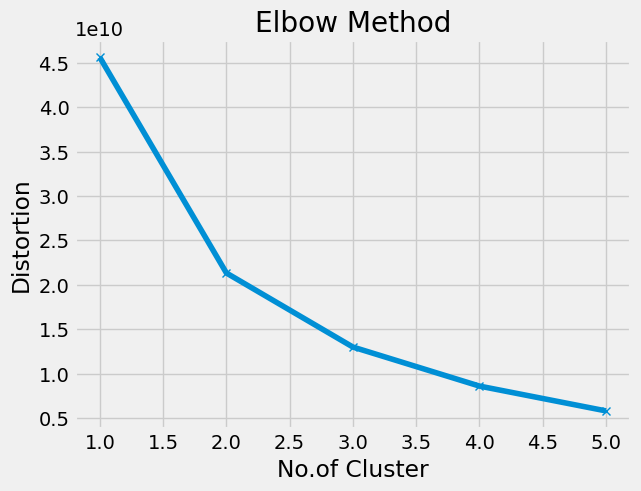

In [20]:
distortion = []
for i in range (1,6):
  km = KMeans(n_clusters=i,init='k-means++',random_state=42,n_init=10)
  km.fit(X_pca)
  distortion.append(km.inertia_)
plt.plot(range(1,6),distortion,marker = 'x')
plt.xlabel("No.of Cluster")
plt.ylabel("Distortion")
plt.title("Elbow Method")
plt.show()

In [21]:
model = KMeans(n_clusters=3,init='k-means++',random_state=42,n_init=10)
model.fit(X_pca)
y = model.predict(X_pca)

In [24]:
y

array([0, 0, 0, ..., 0, 0, 0], dtype=int32)

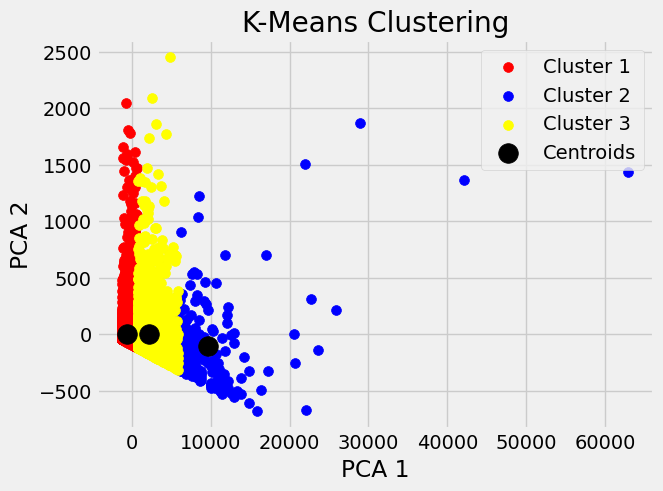

In [26]:
plt.scatter(X_pca.loc[y==0,'PCA 1'],X_pca.loc[y==0,'PCA 2'],s=50,c='red',label = 'Cluster 1')
plt.scatter(X_pca.loc[y==1,'PCA 1'],X_pca.loc[y==1,'PCA 2'],s=50,c='blue',label = 'Cluster 2')
plt.scatter(X_pca.loc[y==2,'PCA 1'],X_pca.loc[y==2,'PCA 2'],s=50,c='yellow',label='Cluster 3')
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=200,c='black',label='Centroids')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clustering")
plt.legend()
plt.show()